# 00 — Sepsis Data Preparation

Mirrors original `01_sepsis_analysis_realcause_preparation.ipynb` exactly.
Reads the raw XES event log and produces `artifacts/sepsis_cases.csv`.

**Run this notebook once before any experiment notebooks.**

In [ ]:
import sys, os
# Add project root so existing cdv_utils imports work
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from cdv_utils.sepsis_loading import *
from cdv_utils.feature_extraction import *
from cdv_utils.analysis_utils import *
from cdv_utils.transform_utils import *

# Output directory
ARTIFACTS_DIR = 'cdv_experiments/sepsis/artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

OUTPUT_CSV = os.path.join(ARTIFACTS_DIR, 'sepsis_cases.csv')
print(f'Output will be saved to: {OUTPUT_CSV}')

Output will be saved to: revised_experiment/sepsis/artifacts\sepsis_cases.csv


## 1. Load Raw Event Log

In [4]:
XES_PATH = 'datasets/Sepsis Cases - Event Log.xes.gz'
assert os.path.exists(XES_PATH), f'Raw XES file not found: {XES_PATH}'

print('Loading sepsis event log...')
df = load_sepsis_data(XES_PATH)
print(f'Loaded {len(df)} events for {df["case_id"].nunique()} cases')

Loading sepsis event log...


parsing log, completed traces ::   0%|          | 0/1050 [00:00<?, ?it/s]

Loaded 15214 events for 1050 cases


## 2. Extract Admission Decisions and Features

In [5]:
df_sepsis = extract_admission_decisions(df)
print(f'Cases with admission decisions: {len(df_sepsis)}')

df_sepsis = extract_activity_sequences(df, df_sepsis)

pre_admission_vars = extract_pre_admission_variables_with_values(df)
df_sepsis['pre_admission_variables'] = df_sepsis['case_id'].map(
    lambda x: ','.join(pre_admission_vars.get(x, []))
)

pre_admission_features = extract_pre_admission_features(df, df_sepsis)
df_sepsis_extended = pd.merge(df_sepsis, pre_admission_features, on='case_id', how='left')
print(f'Extended dataset shape: {df_sepsis_extended.shape}')

Cases with admission decisions: 810
Extended dataset shape: (810, 38)


## 3. Variant Analysis (Elbow Chart)

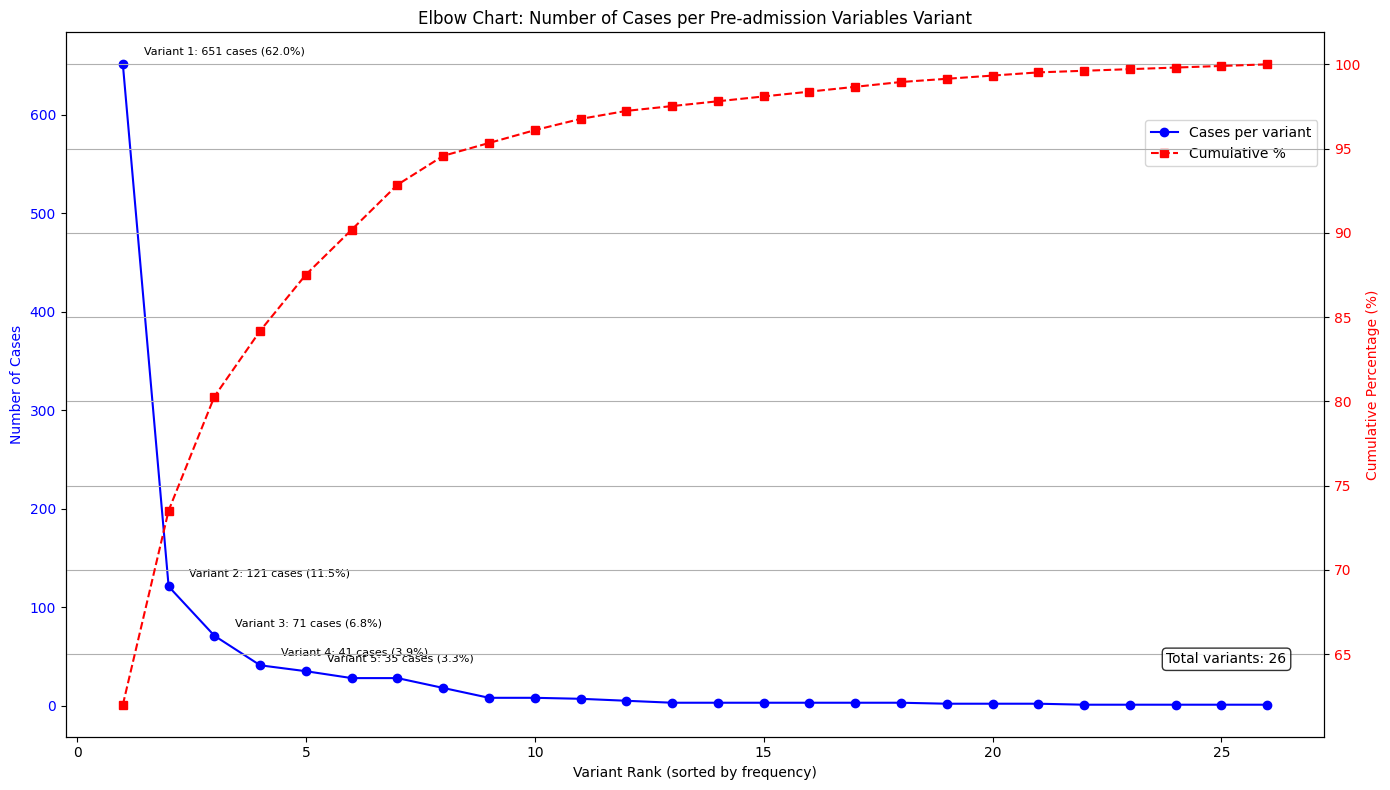

Total number of variants: 26
Most common variant has 651 cases (62.00%)
Top 5 variants cover 919 cases out of 1050 total cases (87.52%)
Number of variants needed to cover 85% of cases: 5


In [6]:
create_variant_elbow_chart(pre_admission_vars, figsize=(14, 8))

# Assign variants with k=1 (same as original NB01)
df_sepsis_extended = assign_variants(df_sepsis_extended, k=1)

## 4. Transformation Pipeline → artifacts/sepsis_cases.csv

In [7]:
df_realcause = complete_transformation_pipeline(
    df_sepsis_extended=df_sepsis_extended,
    outcome_column='cycle_time',
    decision_column='admission_decision',
    treatment_mapping={'IC': 1, 'NC': 0},
    max_outcome_value=65760,
    columns_to_drop=['Diagnose'],
    output_file=OUTPUT_CSV
)

print(f'\nFinal dataset: {df_realcause.shape}')
print(f'Treatment distribution:')
print(df_realcause['t'].value_counts())
print(f'Saved to: {OUTPUT_CSV}')

Starting transformation pipeline...
Step 1 - Initial RealCause format: (810, 37)
Step 2 - Treatment encoded
Step 3 - Boolean columns converted
Filtered dataset: 810 cases (removed 0 outliers)
Step 4 - Outliers filtered: (810, 37)
Dropped columns: ['Diagnose']
Step 5 - Dataset cleaned: (810, 36)
Dataset saved to revised_experiment/sepsis/artifacts\sepsis_cases.csv
Shape: (810, 36)
Columns: ['InfectionSuspected', 'DiagnosticBlood', 'DisfuncOrg', 'SIRSCritTachypnea', 'Hypotensie', 'SIRSCritHeartRate', 'Infusion', 'DiagnosticArtAstrup', 'Age', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther', 'SIRSCriteria2OrMore', 'DiagnosticXthorax', 'SIRSCritTemperature', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 'DiagnosticLacticAcid', 'Hypoxie', 'DiagnosticUrinarySediment', 'DiagnosticECG', 'Leucocytes', 'CRP', 'LacticAcid', 'Leucocytes_2', 'CRP_2', 'LacticAcid_2', 'LacticAcid_3', 'variant', 't', 'y', 'y0', 'y1', 'ite']
Transformation pipeline completed!

Final

## 5. Validation

In [8]:
assert set(df_realcause['t'].dropna().unique()) == {0, 1}, 'Treatment not binary!'
assert not np.isinf(df_realcause.select_dtypes(include=[np.number])).any().any(), 'Infinite values!'
assert df_realcause['y'].min() > 0, 'Non-positive outcome values!'
assert df_realcause.isnull().sum().sum() > 0 or True, 'Unexpected NaN check'  # NaNs are OK (structural absence)

print('All validation checks passed.')
print(f'Dataset ready: {OUTPUT_CSV}')

All validation checks passed.
Dataset ready: revised_experiment/sepsis/artifacts\sepsis_cases.csv
